/var/folders/vc/zqm44p0x6dx4m48jclbr5q280000gn/T/ipykernel_12430/977092667.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(df.values, labels=df.columns, boxprops=boxprops, medianprops=medianprops,


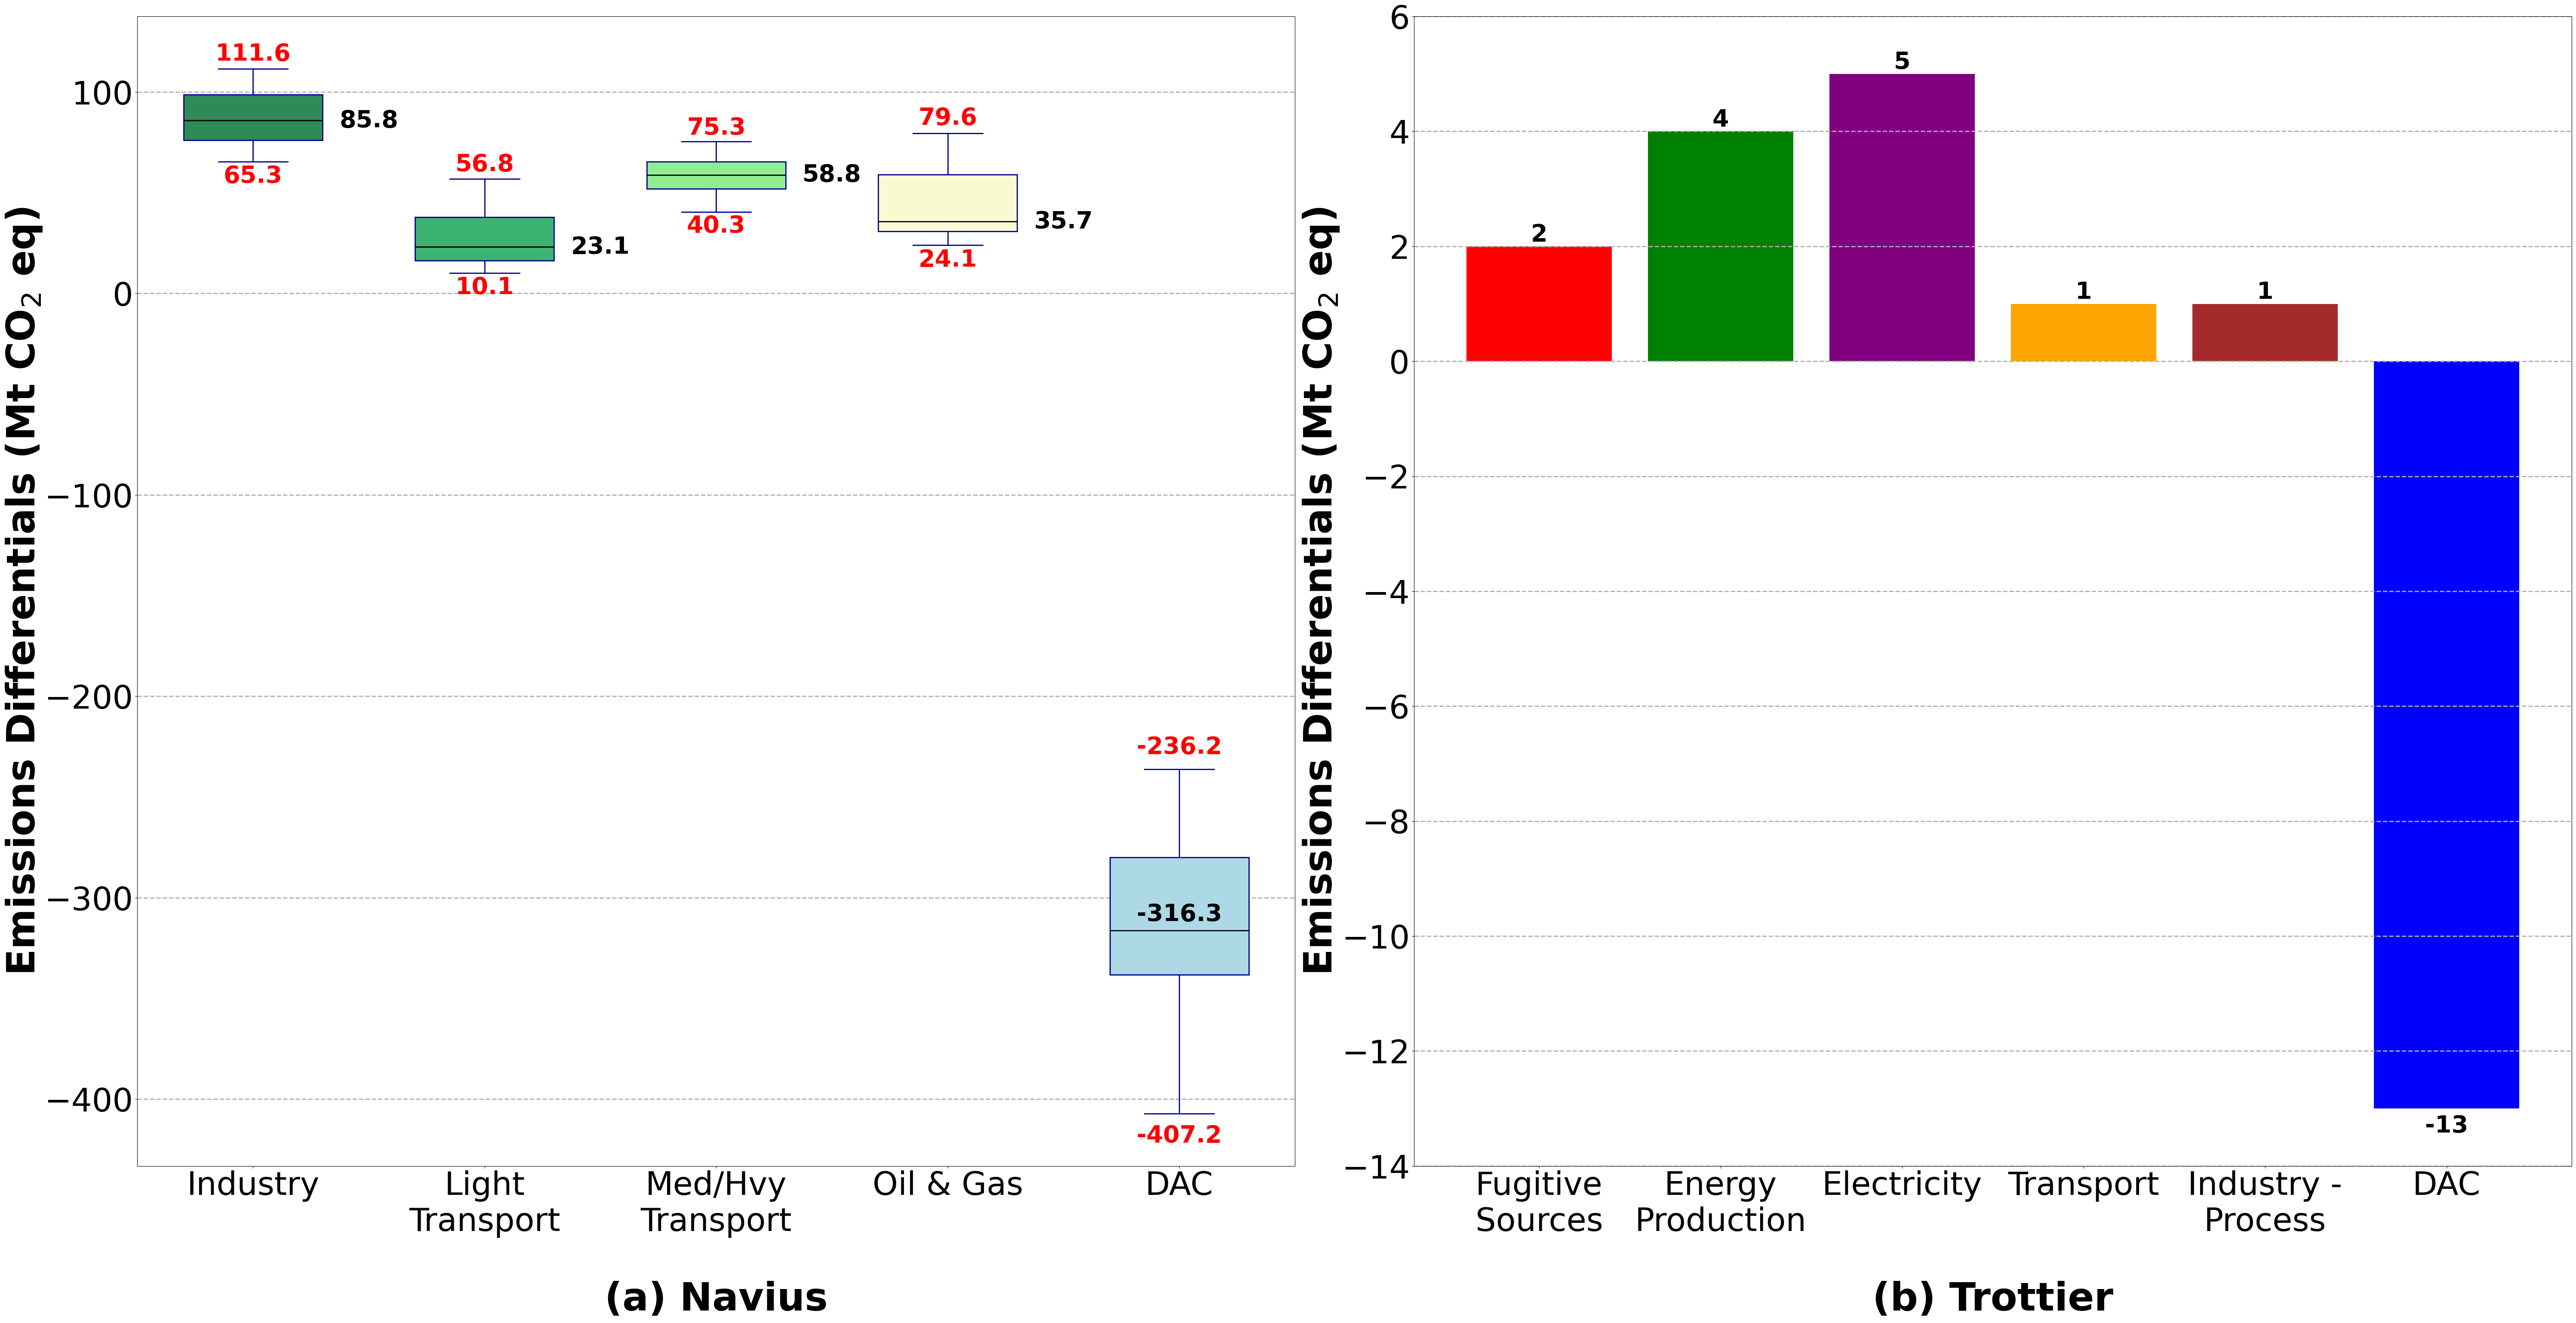

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import textwrap

# Read data from Excel file
df = pd.read_excel("2050 Emissions Deltas - Navius rev01.xlsx")

# Data for bar chart
sectors = ["Fugitive Sources", "Energy Production", "Electricity", "Transport", "Industry - Process", "DAC"]
emissions_differentials = [2, 4, 5, 1, 1, -13]
colors_bar = ['red', 'green', 'purple', 'orange', 'brown', 'blue']

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(60, 30), gridspec_kw={'width_ratios': [1, 1]})  # Equal width ratio

# ------------------- Boxplot (Left Subplot) ------------------- #
ax1 = axes[0]

# Customize boxplot colors
boxprops = dict(linewidth=2, color='darkblue')
medianprops = dict(linewidth=2, color='black')
whiskerprops = dict(linewidth=2, color='darkblue')
capprops = dict(linewidth=2, color='darkblue')

# Create boxplot with customized properties
bp = ax1.boxplot(df.values, labels=df.columns, boxprops=boxprops, medianprops=medianprops,
                whiskerprops=whiskerprops, capprops=capprops, patch_artist=True, widths=0.6)  # Reduced box width

# Set specific colors for each box
colors = ['lightblue'] * len(df.columns)
colors[0] = 'seagreen'
colors[1] = 'mediumseagreen'
colors[2] = 'lightgreen'
colors[3] = 'lightgoldenrodyellow'

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Function to wrap text for tick labels (ensuring it only breaks at spaces)
def wrap_labels(labels, width):
    return ['\n'.join(textwrap.wrap(label, width, break_long_words=False)) for label in labels]

# Wrap x-axis labels with improved spacing
wrapped_labels = wrap_labels(df.columns, 10)

# Add labels for max, min, median
for i, col in enumerate(df.columns):
    ax1.text(i + 1, df[col].max() + 0.03 * (df[col].max() - df[col].min()), f'{df[col].max():.1f}', ha='center', va='bottom', color='red', fontsize=40, fontweight='bold')
    ax1.text(i + 1, df[col].min() - 0.03 * (df[col].max() - df[col].min()), f'{df[col].min():.1f}', ha='center', va='top', color='red', fontsize=40, fontweight='bold')
    if i in [0, 1, 2, 3]:
        ax1.text(i + 1.5, df[col].median(), f'{df[col].median():.1f}', ha='center', va='center', color='black', fontsize=40, fontweight='bold')  # Moved inside box
    else:
        ax1.text(i + 1, df[col].median()+8, f'{df[col].median():.1f}', ha='center', va='center', color='black', fontsize=40, fontweight='bold')  # Moved inside box

# Axis labels and formatting for boxplot
ax1.set_xlabel('(a) Navius', fontsize=65, fontweight='bold', labelpad=40)
ax1.set_ylabel('Emissions Differentials (Mt CO$_2$ eq)', fontsize=65, fontweight='bold', labelpad=1)
ax1.set_xticks(range(1, len(df.columns) + 1))
ax1.set_xticklabels(wrapped_labels, rotation=0, fontsize=54)
ax1.tick_params(axis='y', labelsize=54)
ax1.grid(True, axis = 'y', linestyle='--', linewidth=2)

# ------------------- Bar Chart (Right Subplot) ------------------- #
ax2 = axes[1]
bars = ax2.bar(sectors, emissions_differentials, color=colors_bar)

# Wrap x-axis labels in bar chart to avoid overlap (ensuring whole-word breaks)
wrapped_labels_bar = wrap_labels(sectors, 10)
ax2.set_xticks(range(len(sectors)))
ax2.set_xticklabels(wrapped_labels_bar, rotation=0, fontsize=36)

# Apply stylistic choices from boxplot to bar chart
ax2.set_xlabel("(b) Trottier", fontsize=65, fontweight='bold', labelpad=40)
ax2.set_ylabel("Emissions Differentials (Mt CO$_2$ eq)", fontsize=65, fontweight='bold', labelpad=1)
ax2.tick_params(axis='y', labelsize=54)
ax2.grid(True, axis = 'y', linestyle='--', linewidth=2)
ax2.set_yticks(range(min(emissions_differentials) - min(emissions_differentials) % 2, max(emissions_differentials) + 2, 2))  # Adjusted to show 0 in steps of 2
ax2.tick_params(axis='x', labelsize=54)

# Add data labels on top of the bars (move negative values outside)
for bar, value in zip(bars, emissions_differentials):
    if value < 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.1, f'{value}', ha='center', va='top', fontsize=40, fontweight='bold', color='black')
    else:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value}', ha='center', va='bottom', fontsize=40, fontweight='bold', color='black')

# Adjust subplot layout to align x-labels at the same height
plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.3, wspace=0.3)

ax1.xaxis.set_label_coords(0.5, -0.1)
ax2.xaxis.set_label_coords(0.5, -0.1)

plt.tight_layout()

# Show the figure
plt.show()

